## Ash Kuinkel ~ cosc102 assingment 1

### Brief Overview: 
This program is crafted in two seperate sections to answer the two questions as provided in the task description :

1) **Predator-Prey Population Dynamics** - We are given the relationship between populations of prey (rabbit) and predator
(fox) species (i.e. as predators increase, prey decrease & vice versa), and it is explicitly modelled through differential
equations. For this task, simplicity is prioritised & we are provided the required equations. Under some assumptions; foxes
shall only eat rabbits, unlimited population growth of both species, no external influences, & given constant values (c,d,f,g)
representative of predation/reproduction rates, we need to model the population of our prey & predator in a visual manner, with the help of python/matplotlib/numpys etc. 
### ** FINISH OFF THIS DESCRIPTION FOR Q1 ** 


# Question 1 - Predator-Prey Population Dynamics 

### <u>Imports/Initialisations</u>

We first begin our program by importing the required libraries/modules. Matplotlib is a library whose main purpose is to help us in crafting visualisations in python such as histograms, bar charts, scatter plots, line graphs etc. This is the only one we really need for the first part of this assingment, i.e. question 1. More specifically, we are using the pyplot module which helps us in creating and customising our figure/axes with the methods provided. The reason we've imported it saying **import as plt** is so that we don't have to repeat matplotlib.pyplot every time we want to call a method. Instead we can just refer to it as **plt**. This is reflected in the later parts of the code.

In [22]:
# imports:
import matplotlib.pyplot as plt;

Like solving a problem in any other domain, we follow the same procedure here. Our first step towards making an effort to tackle the problem is always noting the known/gathered information we have at our disposal. This includes the initial values we are given for the populations and the constants. Note that the variable isn't called initial_pop_foxes or initial_pop_rabbits as it wouldn't be refelctive of the variable at all states of the program.

In [23]:
# Rather than having to create 4 different lines for the constant, we can declare them like this:
c,d,f,g = 0.000005,0.3,0.5,0.00001 # This is known as tuple unpacking
pop_foxes = 35000
pop_rabbits = 70000

From our content, i.e. jupyter notebooks from the lectures, we know that to plot the graph of our population models, we should have a list of int/float values that we wish to plot. Hence, we need to begin by initialising the lists, one for the foxes & one for the rabbits, as such:

In [24]:
foxes_sequence_terms = [35000]
rabbits_sequence_terms = [70000]

Note that in the initialisation of the lists above, we first put the initial values into the lists aswell. This is an important point in our discussion here. Say we didn't initialise the lists to e.g. 35,000 & 70,000, it would cause a problem as the first value wouldn't be the initial values of the populations but would rather be the populations after the first time period.

Note that I have named the variables to be foxes/rabbits_sequence_terms. This is actually the correct mathematical name for the model we have been provided in the task description (recursive sequence).

### <u>Core Sequence Logic</u>

We now move onto the chunk of our logic here which ensures that we are using the recursive model provided in the task description to generate 20 points (which are stored in the list fox/rabbit_sequence_terms) for the respective populations and this is the entire dataset required for this problem. Note that this is implemented as a resuable function with adequate documentation through the use of docstrings, as required by the quality of solution part in the marking rubric:

In [25]:
def predator_prey_data_generator(c:float,d:float,f:float,g:float,pop_foxes:float,pop_rabbits:float,time_step:int) -> None:
    '''
    Outputs required dataset for population of prey & predators after 20 time-steps w/ provided model.
    
    Args:
      c (float) : Constant value representing either reproduction or predation rate.
      d (float) : Constant value representing either reproduction or predation rate.
      f (float) : Constant value representing either reproduction or predation rate.
      g (float) : Constant value representing either reproduction or predation rate.
      pop_foxes (float) : Population of foxes at any given time.
      pop_rabbits (float) : Population of rabbits at any given time.
      time_step (int) : Determines over how much time, the model iterates toC. 
    
    Returns:
      (None) : Appends required values to arrays initialised previously.
    '''
    i = 0 # initialise var i to keep track of the amout of times we have iterated through the sequence
    while (i < time_step):
        curr_fox_pop = pop_foxes
        curr_rabbit_pop = pop_rabbits
        
        #Model for population of foxes as provided in the question description:
        pop_foxes = (((c * curr_rabbit_pop) - d) * curr_fox_pop) + curr_fox_pop 
        foxes_sequence_terms.append(pop_foxes) #add term to fox population arr
        
        #Model for population of rabbits as provided in the question description:
        pop_rabbits = ((f - (g * curr_fox_pop)) * curr_rabbit_pop) + curr_rabbit_pop
        rabbits_sequence_terms.append(pop_rabbits) # add term to rabbit population arr
        
        i+=1 # incrementing our variable i with short hand python syntax, i.e. i+=1 instead of i = i + 1

A very important mistake I first made here at first was initialising the models to just:

```python 
pop_foxes = (((c * pop_rabbits) - d) * fox_pop) + fox_pop
pop_rabbits = ((f - (g * pop_foxes)) * pop_rabbits) + pop_rabbits
```

Notice that when we work out pop_foxes, everything would be fine and we would get the intended
value. However, once we pass in that pop_foxes value to the pop_rabbits, we're actually passing the 
updated pop_foxes value. This led me to getting the wrong graph points at first. The solution for this 
problem was to initialise 2 variables to hold the current fox/rabbit population and pass those so that
the updated pop_foxes isn't passed into pop_rabbits. This is made evident within our function, through the two lines:

```python
curr_fox_pop = pop_foxes
curr_rabbit_pop = pop_rabbits
```


*We can now verify that we have populated our lists with the appropriate values, as such:*

In [26]:
#calling our function with the initialised values as such:
predator_prey_data_generator(c,d,f,g,pop_foxes,pop_rabbits,20) 

In [27]:
print(foxes_sequence_terms)

[35000, 36750.0, 40516.875, 46830.67027734375, 56152.703760730394, 68218.52160635527, 80715.90648486368, 88397.24599090994, 86080.05152379734, 74774.30367521863, 60403.23812185969, 47180.90226806577, 36454.88934746249, 28241.98161144092, 22165.15434625838, 17804.98750911231, 14814.4117846488, 12955.893168746981, 12126.221370570143, 12409.632637881228, 14219.514014718696]


In [28]:
print(rabbits_sequence_terms)

[70000, 80500.0, 91166.25, 99811.6594453125, 102975.02003478922, 96639.27210449587, 79033.02543591382, 54757.31525086, 33732.01421596924, 21561.48610683289, 16219.778061836034, 14532.395927226073, 14942.078371206204, 16965.99942037496, 20657.46469406297, 26407.438107631562, 34909.316104906975, 47192.36431837482, 64674.35417266772, 89168.97590203732, 122687.9215166523]


So this concludes the core logic function of the first question, and we are now able to continue and plot these points we've managed to gather!

### <u>Plotting Logic</u>

*Note that attempting to create a function whose params would be highly specific, e.g. x_label, y_label is very much a tedious task, and defeats the point of being able to use the methods available. Hence, there is no need of a function for our plotting logic. Also the entire plotting logic could've been in one cell, but explanations were provided for the blocks of code, hence why are split into different cells (& why we had to prevent displaying plot until all changes took place).*

Initialise the structural figure containing just a single plot axes & plot the points we managed to gather within the lists *fox_sequence_terms* and *rabbits_sequence_terms* by doing as follows:

In [29]:
fig,ax = plt.subplots();

# plotting fox population, w/label foxes for  legend and colour red as required by task:
ax.plot(foxes_sequence_terms,'r',label='Foxes') 
# plotting rabbit population, w/label rabbits for  legend and colour green as required by task:
ax.plot(rabbits_sequence_terms,'g',label='Rabbits')

plt.close(fig) # Don't display until we make all changes, else it wont be truly representative of the plot we have made..

Including the legend with the loc to best, i.e. we let it automatically decide where the best position for the legend is within our graph, & also setting the title of the graph (in bold as required):

In [30]:
ax.legend(loc='best',fontsize='x-small')

ax.set_title("Predator-Prey populations over time",weight='bold')

Text(0.5, 1.0, 'Predator-Prey populations over time')

Formatting the y axis of the graph to include label, and match the intervals as shown in the example plot within task description:

In [31]:
ax.set_ylabel("Population")
ax.set_yticks([0,20000,40000,60000,80000,100000,120000])

Formatting x axis of graph to include label, match intervals shown in example (i.e. 20) 

In [32]:
ax.set_xlabel("Time Step");
x_label_steps = list(range(21))
ax.set_xticks(x_label_steps)
ax.set(xlim=(0,20)) # configure graph to display from 0-20 label, no other extra space needed..

[(0.0, 20.0)]

Configuring colour of the labels, remove the label marks that would otherwise be present, and add faint grid (configured via alpha value) to try and match the example plot exactly:

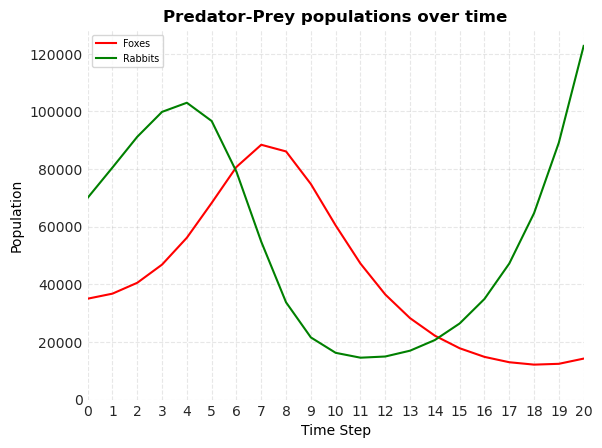

In [33]:
ax.tick_params(length=0,axis='both',labelcolor=(38/255,38/255,38/255)) #Normalisation with the /255

#Disable the tick marks on all the axes:
for spine in ax.spines.values(): 
    spine.set_visible(False)

ax.grid(alpha=0.3,linestyle='--')

display(fig) # Displaying the final plot

Our final step is to now save the plot to a file as required by the assessment task:

In [34]:
#saving figure to file:
fig.savefig("AKuinkelAT1Q1-Predator-Prey-model.png")

# Question 2 - Sampling a Binomial Distribution

### <u>Imports/Initialisations</u>

Once again, we begin with the required imports for our program within the top of the file, we require matplotlib.pyplot for the plot (purpose/function of this explained in previous question), the random module which allows us to generate random numbers, the numpy library which allows us to format our data in a manner which e.g. scikit accepts & the KDE from scikit.

In [35]:
# imports:
import random
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KernelDensity

Initialising the variables we need i.e. n & p, as required by the question. Note that trials is initialised & returned within the main logic function for this program:

In [36]:
n = 12 # number of rows in the galton board
p = 0.5 # probablitiy of a ball moving to the right/left of any pin is 50/50, let's assume p is the probability of a ball moving to the right

### <u>Core Logic (Simulating Process of Galton Board)</u>

We define our function galton_process() here and we follow the algorithm that the question gives us which is just:

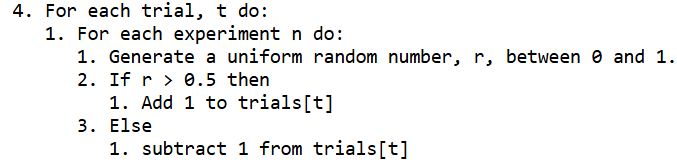

Note that the task description actually never makes use of p, it initialises it and then doesn't access it. But by looking at the task description for question 2, it seems as if the comparison between r > 0.5 should actually be r < p. Because p is the probability that the balls will move to the right, e.g. if we have r < 0.6, we get that 60% probability of moving right & 40% moving left which makes sense. But if we did r > 0.6 for example, it'd mean there's a 60% chance that this moves to the left and a 40% chance that this moves to the right. So hence we use r < p. 

In [37]:
def galton_process(num_of_trials:int, n:int, p:float) -> list:
    '''
    to do: write function docstring...
    '''
    trials = [0] * num_of_trials # initialising trials to hold num_of_trials amount of 0's.
    
    for t in range(num_of_trials): # i.e. for each trial t
        for _ in range(n): # i.e. for each experiment n (also note we use _ as variable name, indicating that the loop variable won't be used within the loop)
            # Generating random uniform number between 0 & 1:
            r = random.random()
            
            if (r < p): # r is num bet. 0 & 1 e.g .6 if we go less than .6 that's probability we move right, greater is probability we move left, we want probability of right so r < p not r > p.
                trials[t] += 1 # ball moves right
            else:
                trials[t] -= 1 # ball moves left
    
    return trials

trials = galton_process(1000,n,p) # Calling our re-usable function with the num_of_trials & vars n/p we initialised earlier.         

This is our trials list generated, we now have what we need to start plotting our histogram and the KDE.

### <u>Plotting Logic</u>

It's important to know that the KernelDensity from SciKit expects a 2d matrix of the shape (n_samples,n_features) (https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KernelDensity.html). But note that currently our trials array is just a regular 1d array, so we must first transform this.

At first I stumbled into this error:


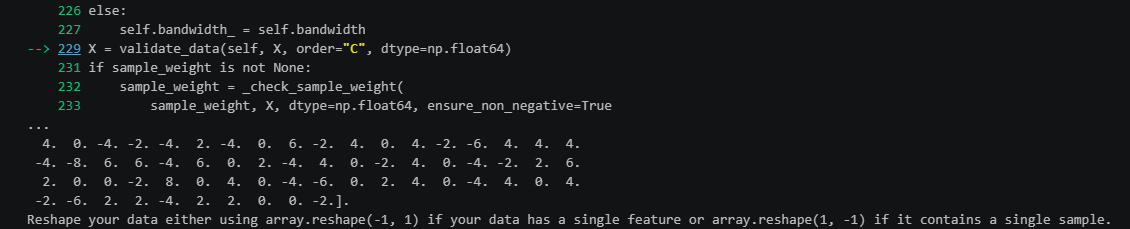


So it goes to show how Scikit's KernelDensity really does require a 2d array & we cater for this requirement as such:

In [38]:
trials = np.array(trials) # transition our trials from a standard python list into a numpy array that's 1d.
trials = trials.reshape(-1,1) # transitions trials from 1d to 2d matrix with num_of_trials rows (sample) and 1 column (feature) 

Our trials is all ready, now let's plot the histogram & the KDE in one plot, with the KDE over the histogram:

[(-12.0, 12.0)]

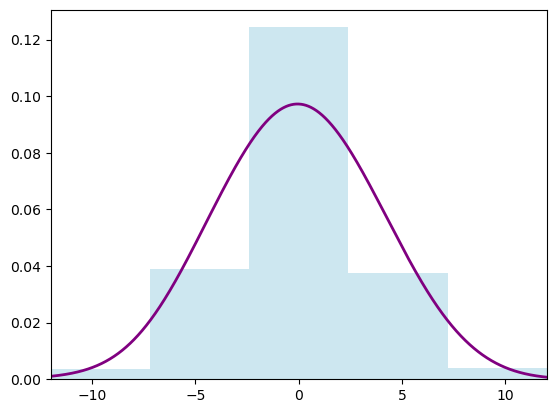

In [ ]:

# initialise figure/axes:
fig,ax = plt.subplots()

bins = np.linspace(-12,12,6) # splits range of -12 to 12 into intervals, so histogram isn't plotting the actual values e.g. 2, just the counts of respective intervals between -12 & 12.

# plotting the histogram, making it semi transparent as we will just display the KDE over it:
ax.hist(trials,bins=bins,color='lightblue',alpha=.6,density=True) # the density param makes it so that y axis is showing probability density & area of all bars within histogram add up to 1. 
 
# Gaussian KDE logic (i picked it over other KDE e.g. ) + plot:
X_plot = np.linspace(-12,12,2000).reshape(-1,1) # dividing -12 to 12 into 2000 tiny intervals to help draw our curve & transform into 2d matrix w/ 2000 rows & 1 column so kde.score_samples accepts it

kde = KernelDensity(kernel='gaussian',bandwidth=2).fit(trials) # we're essientially training the non-parametric model w/ trials (a 2d matrix). Bandwith 2 helps transform our curve into a smooth one.
# KernelDensity calculuates density value for our 2000 intervals & because the ones close to the endpoints would be like 0.0000321 etc. it just takes the log of all nums start to finsh so that the
# process is less likey to face errors on computer memory storing tiny decimal points as e.g. ln(0.0000321) = -10.34665 (easier to store):
log_dens = kde.score_samples(X_plot) 
ax.plot(X_plot[:, 0],np.exp(log_dens),'purple',linewidth=2) # extract first column only with X_plot[:,0], undo the logs by raising them to power of e so we plot real density values for gaussian KDE

ax.set(xlim=[-12,12])

# to do: add plot labels, title, legend etc. & answer questions